In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset

In [3]:
emotion_dataset = load_dataset('dair-ai/emotion')
train_text      = emotion_dataset['train']['text']
train_label     = emotion_dataset['train']['label']

test_text       = emotion_dataset['test']['text']
test_label      = emotion_dataset['test']['label']


README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  129kB            

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [4]:
label_names = emotion_dataset['train'].features['label'].names

In [5]:
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [6]:
df_train = pd.DataFrame(
    {
        'text'  : train_text,
        'label' : [label_names[i] for i in train_label]
    }
)

df_test = pd.DataFrame(
    {
        'text'  : test_text,
        'label' : [label_names[i] for i in test_label]
    }
)

In [7]:
df_test.head()

,text,label
0,im feeling rather rotten so im not very ambiti...,sadness
1,im updating my blog because i feel shitty,sadness
2,i never make her separate from me because i do...,sadness
3,i left with my bouquet of red and yellow tulip...,joy
4,i was feeling a little vain when i did this one,sadness


In [8]:
df_train.shape

(16000, 2)

<Axes: xlabel='label', ylabel='Count'>

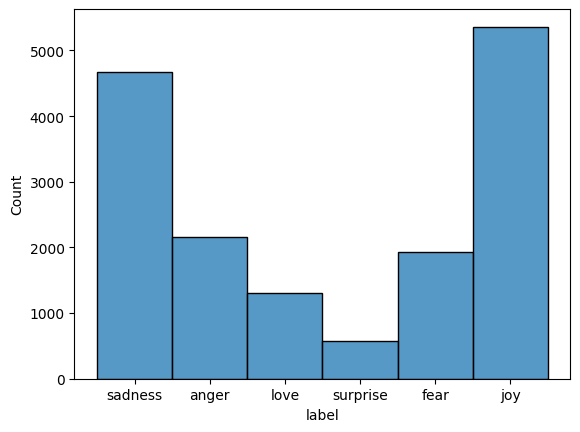

In [9]:
sns.histplot(df_train['label'])

In [10]:
import re
import string
#remove punctuation
df_train['text'] = df_train['text'].str.translate(str.maketrans('', '', string.punctuation))
#remove numbers
df_train['text'] = df_train['text'].str.replace(r'\d+', '', regex=True)
# Remove HTML tags
df_train['text'] = df_train['text'].str.replace(r'<.*?>', '', regex=True)
# Remove URLs
df_train['text'] = df_train['text'].str.replace(r'http\S+|www\S+', '', regex=True)
#Remove emojis
df_train['text'] = df_train['text'].str.replace(r'[\U00010000-\U0010ffff]','', regex=True)

In [11]:
df_train.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [12]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words = 10000
max_len = 100
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df_train['text'])
sequences = tokenizer.texts_to_sequences(df_train['text'])
padded_sequences = pad_sequences(sequences, maxlen=max_len)

In [13]:
sequences_test = tokenizer.texts_to_sequences(df_test['text'])
padded_sequences_test = pad_sequences(sequences_test, maxlen=max_len)

In [14]:
sequences[0]

[1, 138, 2, 678]

In [15]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_train['label'] = le.fit_transform(df_train['label'])
df_test['label'] = le.transform(df_test['label'])

In [16]:
df_train['label'].value_counts()

,count
label,
2,5362
4,4666
0,2159
1,1937
3,1304
5,572


SIMPLE RNN

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense,LSTM,GRU,Dropout
rnn=Sequential([
    Embedding(input_dim=max_words,output_dim=128,input_length=max_len),
    SimpleRNN(units=128,activation='relu',return_sequences=True),
    Dropout(0.2),
    SimpleRNN(units=64,activation='relu'),
    Dropout(0.2),
    Dense(units=64,activation='relu'),
    Dense(units=len(label_names),activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [18]:
rnn.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [19]:
rnn.fit(padded_sequences,df_train['label'],epochs=10,validation_split=0.2)

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.3769 - loss: 1.4025 - val_accuracy: 0.5503 - val_loss: 1.0311
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.7156 - loss: 0.6814 - val_accuracy: 0.7591 - val_loss: 0.5386
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.7860 - loss: 0.5305 - val_accuracy: 0.7934 - val_loss: 0.5215
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8595 - loss: 0.3794 - val_accuracy: 0.8216 - val_loss: 0.5310
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9225 - loss: 0.2386 - val_accuracy: 0.8834 - val_loss: 0.3950
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9234 - loss: 0.2361 - val_accuracy: 0.8697 - val_loss: 0.5402
Epoch 7/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9454 - loss: 0.1611 - val_accuracy: 0.8966 - val_loss: 0.4119
Epoch 8/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9601 - loss: 0.1248 - val_acc

In [20]:
rnn_loss, rnn_accuracy = rnn.evaluate(padded_sequences_test, df_test['label'])
print(f"RNN Loss: {rnn_loss}")
print(f"RNN Accuracy: {rnn_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8935 - loss: 0.4181
RNN Loss: 0.4180622398853302
RNN Accuracy: 0.8934999704360962


LSTM

In [21]:
lstm=Sequential([
    Embedding(input_dim=max_words,output_dim=128,input_length=max_len),
    LSTM(units=128,activation='relu',return_sequences=True),
    Dropout(0.2),
    LSTM(units=64,activation='relu'),
    Dropout(0.2),
    Dense(units=64,activation='relu'),
    Dense(units=len(label_names),activation='softmax')
])
lstm.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
lstm.fit(padded_sequences,df_train['label'],epochs=10,validation_split=0.2)
lstm_loss, lstm_accuracy = lstm.evaluate(padded_sequences_test, df_test['label'])
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - accuracy: 0.4452 - loss: 1.4047 - val_accuracy: 0.6781 - val_loss: 3.1815
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.6796 - loss: 1.2284 - val_accuracy: 0.7434 - val_loss: 0.7072
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.7945 - loss: 0.5865 - val_accuracy: 0.7909 - val_loss: 0.6182
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.8502 - loss: 0.4327 - val_accuracy: 0.8391 - val_loss: 0.5279
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.8841 - loss: 0.3305 - val_accuracy: 0.8534 - val_loss: 0.5167
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9222 - loss: 0.2383 - val_accuracy: 0.8637 - val_loss: 0.4803
Epoch 7/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.8818 - loss: 27.8035 - val_accuracy: 0.6572 - val_loss: 1.6719
Epoch 8/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.8036 - loss: 0.6016 - val_ac

GRU

In [22]:
gru=Sequential([
    Embedding(input_dim=max_words,output_dim=128,input_length=max_len),
    GRU(units=128,activation='relu',return_sequences=True),
    Dropout(0.2),
    GRU(units=64,activation='relu'),
    Dropout(0.2),
    Dense(units=64,activation='relu'),
    Dense(units=len(label_names),activation='softmax')
])
gru.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
gru.fit(padded_sequences,df_train['label'],epochs=10,validation_split=0.2)
gru_loss, gru_accuracy = gru.evaluate(padded_sequences_test, df_test['label'])
print(f"GRU Loss: {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - accuracy: 0.4848 - loss: 1.2392 - val_accuracy: 0.7262 - val_loss: 0.6264
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.8059 - loss: 0.4865 - val_accuracy: 0.8678 - val_loss: 0.3780
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.9109 - loss: 0.2434 - val_accuracy: 0.9153 - val_loss: 0.2324
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.9478 - loss: 0.1402 - val_accuracy: 0.9303 - val_loss: 0.2030
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 16s 27ms/step - accuracy: 0.9602 - loss: 0.1049 - val_accuracy: 0.9278 - val_loss: 0.2006
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9680 - loss: 0.0838 - val_accuracy: 0.9234 - val_loss: 0.2532
Epoch 7/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9728 - loss: 0.0715 - val_accuracy: 0.9287 - val_loss: 0.2420
Epoch 8/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9762 - loss: 0.0611 - v

In [24]:
from tensorflow.keras.layers import Bidirectional
bigru=Sequential([
    Embedding(input_dim=max_words,output_dim=128,input_length=max_len),
    Bidirectional(GRU(units=128,activation='relu',return_sequences=True)),
    Dropout(0.2),
    Bidirectional(GRU(units=64,activation='relu')),
    Dropout(0.2),
    Dense(units=64,activation='relu'),
    Dense(units=len(label_names),activation='softmax')
])
bigru.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
bigru.fit(padded_sequences,df_train['label'],epochs=10,validation_split=0.2)
bigru_loss, bigru_accuracy = bigru.evaluate(padded_sequences_test, df_test['label'])
print(f"BiGRU Loss: {bigru_loss}")
print(f"BiGRU Accuracy: {bigru_accuracy}")

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


400/400 ━━━━━━━━━━━━━━━━━━━━ 30s 49ms/step - accuracy: 0.5059 - loss: 276094.8125 - val_accuracy: 0.7422 - val_loss: 0.6818
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 22s 55ms/step - accuracy: 0.8752 - loss: 0.3593 - val_accuracy: 0.9203 - val_loss: 0.2255
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 22s 55ms/step - accuracy: 0.9423 - loss: 0.1523 - val_accuracy: 0.9178 - val_loss: 0.2228
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 18s 45ms/step - accuracy: 0.9598 - loss: 0.1039 - val_accuracy: 0.9166 - val_loss: 0.2553
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 18s 45ms/step - accuracy: 0.9718 - loss: 0.0808 - val_accuracy: 0.9216 - val_loss: 0.2379
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - accuracy: 0.9776 - loss: 0.0609 - val_accuracy: 0.9156 - val_loss: 0.2704
Epoch 7/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - accuracy: 0.9814 - loss: 0.0526 - val_accuracy: 0.9178 - val_loss: 0.2875
Epoch 8/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 18s 45ms/step - accuracy: 0.9856 - loss: 0.0463 - val_ac

In [27]:
rank=pd.DataFrame({
    'Model':['RNN','LSTM','GRU','bigru'],
    'Loss':[rnn_loss,lstm_loss,gru_loss,bigru_loss],
    'Accuracy':[rnn_accuracy,lstm_accuracy,gru_accuracy,bigru_accuracy]
})
rank

,Model,Loss,Accuracy
0,RNN,0.418062,0.8935
1,LSTM,0.528015,0.8530
2,GRU,0.301852,0.9230
3,bigru,0.411987,0.9125


In [28]:
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')

sample_predictions = np.argmax(gru.predict(sample_padded_sequences), axis=1)

for i in range(len(sample_texts)):
  print(f'Text: {sample_texts[i]}\nPredicted Emotion: {label_names[sample_predictions[i]]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Text: I can't believe how happy I am right now, this is amazing!
Predicted Emotion: sadness
Text: I feel so alone and hopeless today.
Predicted Emotion: fear
Text: I am furious that they cancelled the trip at the last minute.
Predicted Emotion: sadness
Text: I feel terrified when walking down dark alleyways alone.
Predicted Emotion: joy
Text: I was shocked and completely surprised by the unexpected gift!
Predicted Emotion: surprise


In [29]:
gru.save('gru.keras')
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)